In [111]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('house-prices-advanced-regression-techniques')

print("Path to competition files:", path)

Path to competition files: C:\Users\axeld\.cache\kagglehub\competitions\house-prices-advanced-regression-techniques


In [112]:
from pathlib import Path
import pandas as pd

data_dir = Path(path)

print([file.name for file in data_dir.iterdir()])

train_data = pd.read_csv(data_dir / "train.csv")
train_data.head()

['data_description.txt', 'sample_submission.csv', 'test.csv', 'train.csv']


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [113]:
train_data.select_dtypes(include=["number"]).std()

Id                 421.610009
MSSubClass          42.300571
LotFrontage         24.284752
LotArea           9981.264932
OverallQual          1.382997
OverallCond          1.112799
YearBuilt           30.202904
YearRemodAdd        20.645407
MasVnrArea         181.066207
BsmtFinSF1         456.098091
BsmtFinSF2         161.319273
BsmtUnfSF          441.866955
TotalBsmtSF        438.705324
1stFlrSF           386.587738
2ndFlrSF           436.528436
LowQualFinSF        48.623081
GrLivArea          525.480383
BsmtFullBath         0.518911
BsmtHalfBath         0.238753
FullBath             0.550916
HalfBath             0.502885
BedroomAbvGr         0.815778
KitchenAbvGr         0.220338
TotRmsAbvGrd         1.625393
Fireplaces           0.644666
GarageYrBlt         24.689725
GarageCars           0.747315
GarageArea         213.804841
WoodDeckSF         125.338794
OpenPorchSF         66.256028
EnclosedPorch       61.119149
3SsnPorch           29.317331
ScreenPorch         55.757415
PoolArea  

In [114]:
train_data["MSSubClass"].value_counts()

MSSubClass
20     536
60     299
50     144
120     87
30      69
160     63
70      60
80      58
90      52
190     30
85      20
75      16
45      12
180     10
40       4
Name: count, dtype: int64

In [115]:
len(train_data)

1460

In [116]:
train_data.isna().sum().sort_values(ascending=False)

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64

In [117]:
from pandas import DataFrame

label_col = "SalePrice"

def get_only_numeric_x(df: DataFrame):
    return df.select_dtypes(include="number").drop(columns=[label_col])

def get_all_x(df: DataFrame):
    X = df.drop(columns=[label_col, "Id"])
    X["MSSubClass"] = X["MSSubClass"].astype("category")
    return X

def get_x(df: DataFrame):
    df = df.drop(columns=[label_col, "Id"])

def get_y(df: DataFrame):
    return df[label_col]

X = get_all_x(train_data)
y = get_y(train_data)

In [118]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15, random_state=42)

In [119]:
summary = pd.DataFrame({
    "unique_values": X_train.nunique(dropna=False),
    "most_common_value": X_train.apply(
        lambda col: col.value_counts(dropna=False).index[0]
    ),
    "most_common_fraction": X_train.apply(
        lambda col: col.value_counts(dropna=False, normalize=True).iloc[0]
    ),
    "missing_fraction": X_train.isna().mean()
}).sort_values("most_common_fraction", ascending=False)

summary.head(20)

,unique_values,most_common_value,most_common_fraction,missing_fraction
Utilities,1,AllPub,1.000000,0.000000
Street,2,Pave,0.996205,0.000000
PoolArea,6,0,0.995256,0.000000
PoolQC,4,NaN,0.995256,0.995256
Condition2,8,Norm,0.990512,0.000000
3SsnPorch,15,0,0.982922,0.000000
RoofMatl,6,CompShg,0.982922,0.000000
LowQualFinSF,18,0,0.981973,0.000000
Heating,5,GasA,0.976281,0.000000
MiscVal,19,0,0.960152,0.000000


In [120]:
label_col = "SalePrice"
nn_drop = [label_col, "Id", "Fence"]

mostly_constant_cols = summary.index[
    summary["most_common_fraction"] >= 0.99
].to_list()

sorted_errors = summary.sort_values("missing_fraction", ascending=False)
many_errors = sorted_errors.index[
    sorted_errors["missing_fraction"] >= 0.90
].to_list()

to_remove = list(set(nn_drop + mostly_constant_cols + many_errors))

print(to_remove)

def get_nn_x(df: DataFrame, add_columns: bool = False):
    X = df.drop(columns=to_remove)
    X["MSSubClass"] = X["MSSubClass"].astype("category")

    if add_columns:
        X["TotalSF"] = (
            X["TotalBsmtSF"] + X["1stFlrSF"] + X["2ndFlrSF"]
        )
        X["TotalBath"] = (
            X["FullBath"] + 0.5 * X["HalfBath"]
            + X["BsmtFullBath"] + 0.5 * X["BsmtHalfBath"]
        )
        X["HouseAge"] = X["YrSold"] - X["YearBuilt"]
        X["YearsSinceRemodel"] = X["YrSold"] - X["YearRemodAdd"]

    return X

X = get_nn_x(train_data)

['Utilities', 'Fence', 'MiscFeature', 'Id', 'Alley', 'PoolQC', 'PoolArea', 'Street', 'SalePrice', 'Condition2']


In [121]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15, random_state=42)

In [122]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer([
    (
        "numeric",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        make_column_selector(dtype_include="number")
    ),
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),
        make_column_selector(dtype_include=["str", "object", "category"])
    )
])

In [123]:
train_transformed = preprocessor.fit_transform(X_train)
val_transformed = preprocessor.transform(X_val)
test_transformed = preprocessor.transform(X_test)

In [124]:
import torch

torch.manual_seed(42)

device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
device

'cuda'

In [125]:
import numpy as np
from scipy import sparse
from torch.utils.data import TensorDataset, DataLoader

def make_dataset(X_transformed, y):
    if sparse.issparse(X_transformed):
        X_transformed = X_transformed.toarray()

    X_tensor = torch.from_numpy(
        np.asarray(X_transformed, dtype=np.float32)
    )
    y_tensor = torch.from_numpy(
        np.asarray(y, dtype=np.float32).reshape(-1, 1)
    )

    return TensorDataset(X_tensor, y_tensor)

In [134]:
@torch.no_grad()
def eval(model, val_loader, criterion, metric):
    model.eval()
    metric.reset()

    total_loss = 0.0
    total_samples = 0

    for x_dense, x_cat, y in val_loader:
        x_dense = x_dense.to(device)
        x_cat = x_cat.to(device)
        y = y.to(device)

        predictions = model(x_dense, x_cat)
        loss = criterion(predictions, y)

        total_loss += loss.item() * len(y)
        total_samples += len(y)

        metric.update(predictions, y)

    return {
        "loss": total_loss / total_samples,
        "metric": metric.compute().item()
    }


from copy import deepcopy

def train(model, train_loader, val_loader, criterion, optimizer, metric, n_epochs, scheduler, verbose: bool = False, early_stopping_patience: int = 25):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_metric": []
    }
    best_loss = float("inf")
    best_state = None
    bad_epochs = 0

    for epoch in range(n_epochs):
        model.train()
        metric.reset()

        total_loss = 0.0
        total_samples = 0

        for x_dense, x_cat, y in train_loader:
            x_dense = x_dense.to(device)
            x_cat = x_cat.to(device)
            y = y.to(device)

            predictions = model(x_dense, x_cat)

            optimizer.zero_grad()

            loss = criterion(predictions, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(y)
            total_samples += len(y)

        train_loss = total_loss / total_samples
        val = eval(model, val_loader, criterion, metric)
        scheduler.step(val["loss"])

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val["loss"])
        history["val_metric"].append(val["metric"])

        if verbose:
            print(
                f"Epoch: {epoch + 1} | "
                f"Train loss: {train_loss} | "
                f"Val loss: {val["loss"]} | "
                f"Val metric: {val["metric"]}"
            )

        if val["loss"] < best_loss:
            best_loss = val["loss"]
            best_state = deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= early_stopping_patience:
            print("Stopping early...")
            break

    model.load_state_dict(best_state)

    return history


In [156]:
import torch.nn as nn

class HousingNet(nn.Module):
    def __init__(self, n_dense, category_counts, embedding_sizes, dropout: int = 0.1):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(count, size, padding_idx=0)
            for count, size in zip(category_counts, embedding_sizes)
        ])

        self.network = nn.Sequential(
            nn.Linear(n_dense + sum(embedding_sizes), 128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x_dense, x_cat):
        embedded = [
            embedding(x_cat[:, i])
            for i, embedding in enumerate(self.embeddings)
        ]
        combined = torch.cat([x_dense, *embedded], dim=1)
        return self.network(combined)

In [144]:
def make_embedding_dataset(x_dense, x_cat, y):
    if sparse.issparse(x_dense):
        x_dense = x_dense.toarray()

    return TensorDataset(
        torch.tensor(np.asarray(x_dense), dtype=torch.float32),
        torch.tensor(x_cat, dtype=torch.long),
        torch.tensor(np.asarray(y).reshape(-1, 1), dtype=torch.float32)
    )

In [143]:
embedding_dims = {
    "Neighborhood": 4,
    "MSSubClass": 3,
    "Exterior1st": 3,
}

embedding_cols = list(embedding_dims)

def categorical_values(df):
    return (
        df[embedding_cols]
        .astype("string")
        .fillna("__missing__")
        .to_numpy(dtype=str)
    )

In [157]:
from sklearn.model_selection import KFold
from sklearn.base import clone
from torch.utils.data import DataLoader
from sklearn.preprocessing import OrdinalEncoder
from torchmetrics.regression import MeanSquaredError


cv = KFold(n_splits=5, shuffle=True, random_state=42)

fold_scores = []
histories = []
oof_log_predictions = np.empty(len(X_temp))

for fold, (train_idx, val_idx) in enumerate(cv.split(X_temp), start=1):
    print(f"Fold {fold}")
    torch.manual_seed(42 + fold)

    X_fold_train = X_temp.iloc[train_idx]
    X_fold_val = X_temp.iloc[val_idx]
    y_fold_train = y_temp.iloc[train_idx]
    y_fold_val = y_temp.iloc[val_idx]

    cat_encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1,
        dtype=np.int64
    )

    cat_train = cat_encoder.fit_transform(
        categorical_values(X_fold_train)
    ) + 1
    cat_val = cat_encoder.transform(
        categorical_values(X_fold_val)
    ) + 1

    category_counts = [
        len(categories) + 1
        for categories in cat_encoder.categories_
    ]

    fold_preprocessor = clone(preprocessor)
    dense_train = fold_preprocessor.fit_transform(X_fold_train.drop(columns=embedding_cols))
    dense_val = fold_preprocessor.transform(X_fold_val.drop(columns=embedding_cols))

    fold_scaler = StandardScaler()
    y_train_t = fold_scaler.fit_transform(
        np.log(y_fold_train.to_numpy()).reshape(-1, 1)
    )
    y_val_t = fold_scaler.transform(
        np.log(y_fold_val.to_numpy()).reshape(-1, 1)
    )

    fold_train_dataset = make_embedding_dataset(
        dense_train, cat_train, y_train_t
    )
    fold_val_dataset = make_embedding_dataset(
        dense_val, cat_val, y_val_t
    )

    fold_train_loader = DataLoader(
        fold_train_dataset,
        batch_size=32,
        shuffle=True,
    )
    fold_val_loader = DataLoader(
        fold_val_dataset,
        batch_size=32,
        shuffle=False,
    )

    fold_model = HousingNet(
        n_dense=dense_train.shape[1],
        category_counts=category_counts,
        embedding_sizes=[
            embedding_dims[col] for col in embedding_cols
        ],
        dropout=0
    ).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(fold_model.parameters())
    metric = MeanSquaredError(squared=False).to(device)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-5
    )

    history = train(
        fold_model,
        fold_train_loader,
        fold_val_loader,
        criterion,
        optimizer,
        metric,
        n_epochs=300,
        scheduler=scheduler
    )
    histories.append(history)

    fold_model.eval()
    with torch.no_grad():
        predictions_scaled = np.concatenate([
            fold_model(
                x_dense.to(device),
                x_cat.to(device),
            ).cpu().numpy()
            for x_dense, x_cat, _ in fold_val_loader
        ])

    predictions_log = fold_scaler.inverse_transform(
        predictions_scaled
    ).ravel()

    oof_log_predictions[val_idx] = predictions_log

    score = np.sqrt(np.mean(
        (predictions_log - np.log(y_fold_val.to_numpy())) ** 2
    ))
    fold_scores.append(score)
    print(f"Fold {fold} log RMSE: {score:.4f}")

print(
    f"Mean fold log RMSE: {np.mean(fold_scores):.4f} +- {np.std(fold_scores):.4f}"
)

oof_log_rmse = np.sqrt(np.mean(
    (oof_log_predictions - np.log(y_temp.to_numpy())) ** 2
))
oof_dollar_rmse = np.sqrt(np.mean(
    (np.exp(oof_log_predictions) - y_temp.to_numpy()) ** 2
))

print(f"Overall out-of-fold log RMSE: {oof_log_rmse:.4f}")
print(f"Overall out-of-fold dollar RMSE: ${oof_dollar_rmse:,.0f}")

Fold 1
Stopping early...
Fold 1 log RMSE: 0.1142
Fold 2
Stopping early...
Fold 2 log RMSE: 0.1314
Fold 3
Stopping early...
Fold 3 log RMSE: 0.1466
Fold 4
Stopping early...
Fold 4 log RMSE: 0.1138
Fold 5
Stopping early...
Fold 5 log RMSE: 0.1317
Mean fold log RMSE: 0.1275 +- 0.0123
Overall out-of-fold log RMSE: 0.1281
Overall out-of-fold dollar RMSE: $27,675


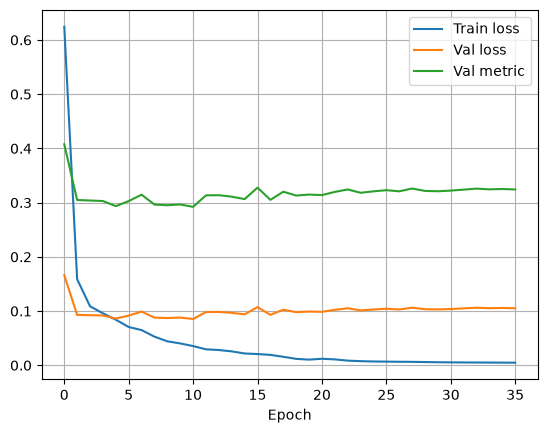

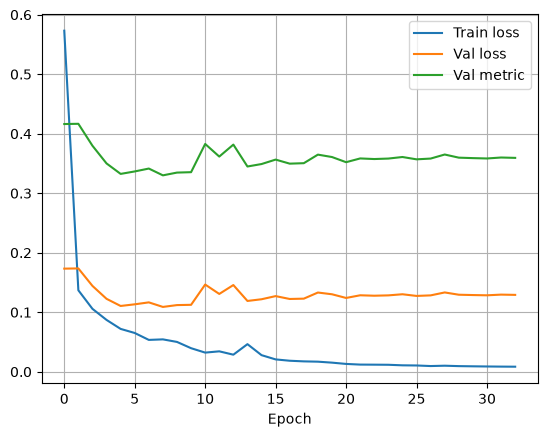

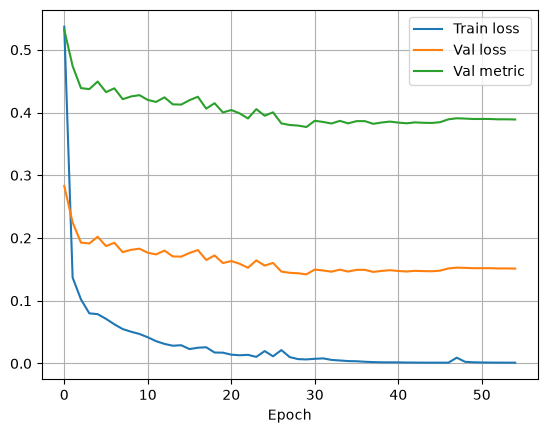

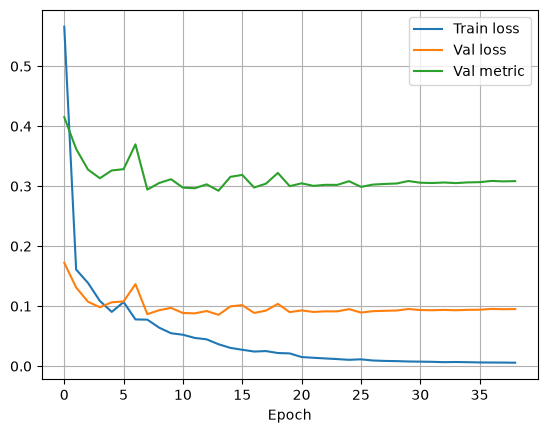

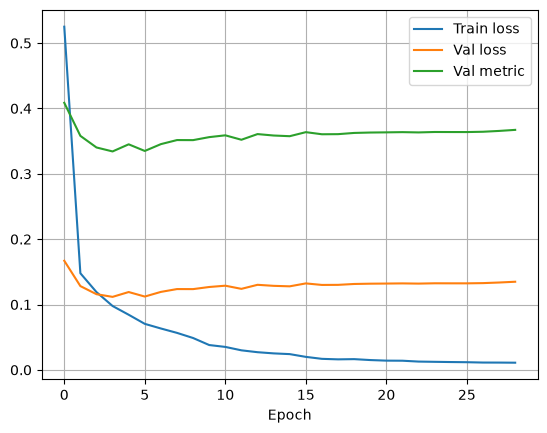

In [158]:
import matplotlib.pyplot as plt

for history in histories:
    epochs = range(len(history["train_loss"]))

    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["val_loss"], label="Val loss")
    plt.plot(epochs, history["val_metric"], label="Val metric")

    plt.grid(True)
    plt.xlabel("Epoch")
    plt.legend()

    plt.show()